# 02 - Data Analysis

This notebook explores the cleaned BreathWatch dataset (data/clean/cleaned_data.csv) through univariate and multivariate visualizations to identify distributions, relationships, and outliers between pollutants, environmental conditions, and health risk indices across the 30 countries from 2015-2024. 

In [34]:
# Setups and imports

import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

%matplotlib inline 

pollution_df = pd.read_csv('../data/clean/cleaned_data.csv')
with pd.option_context('display.max_columns', None):
    display(pollution_df.head())

,Date,Year,Month,Season,Country,City,Latitude,Longitude,Population_Density_per_km2,Green_Cover_Pct,AQI,AQI_Category,Pollution_Alert_Level,PM2_5_ugm3,PM10_ugm3,NO2_ugm3,SO2_ugm3,CO_mgm3,O3_ugm3,VOC_ugm3,NH3_ugm3,Lead_Pb_ugm3,Benzene_ugm3,Formaldehyde_ugm3,Black_Carbon_ugm3,Temperature_C,Humidity_Pct,Wind_Speed_kmh,Wind_Direction,Atmospheric_Pressure_hPa,Visibility_km,Weather_Condition,Primary_Pollution_Source,Industry_Nearby,Traffic_Density,Health_Effects,Associated_Diseases,Respiratory_Risk_Index,Cardiovascular_Risk_Index,Cancer_Risk_Index,Daily_Mortality_Risk,Exceeds_WHO_PM25_Standard,WHO_PM25_Guideline_ugm3,Continent
0,2015-01-01,2015,1,Winter,South Africa,Pretoria,16.8918,-121.5033,43438,8.8,213,Very Unhealthy,Emergency,106.81,239.70,217.49,69.66,6.44,113.43,17.95,61.19,0.1503,7.995,5.63,25.19,18.0,70.8,24.0,N,1027.3,7.34,Windy,Mining Operations,Yes,Medium,Health alert: serious health effects for every...,"Lung Cancer Risk, Heart Attack, Arrhythmia, Pr...",42.6,35.5,0.813,High,Yes,15,Africa
1,2015-01-02,2015,1,Winter,Egypt,Alexandria,40.8396,102.2501,28764,15.5,449,Hazardous,Hazardous Emergency,199.32,300.26,378.61,179.15,32.25,84.95,196.48,69.25,1.2667,12.534,14.02,27.30,-4.3,13.8,28.0,W,1005.1,4.39,Rainy,Power Plants (Gas),Yes,Very High,Health emergency: everyone is affected; life-t...,"Severe COPD, Heart Failure, Lung Cancer, Neuro...",89.8,74.8,3.441,Very High,Yes,15,Africa
2,2015-01-02,2015,1,Winter,Iran,Tehran,-40.7591,7.5925,22808,20.9,172,Unhealthy,Warning,99.62,177.13,14.40,4.71,6.38,174.60,24.05,27.17,0.0599,12.664,29.13,8.86,30.6,12.6,4.8,N,964.7,7.85,Clear,Garbage Burning,Yes,Medium,Everyone may experience health effects; sensit...,"COPD, Ischemic Heart Disease, Stroke Risk, Lun...",34.4,28.7,1.336,Moderate,Yes,15,Asia
3,2015-01-03,2015,1,Winter,South Korea,Daegu,21.9019,97.7119,20332,51.9,220,Very Unhealthy,Emergency,123.08,291.93,203.92,13.25,2.63,82.78,69.01,3.20,1.2077,0.488,41.62,4.75,43.5,63.1,25.9,SW,968.8,7.25,Smoggy,Pesticide Spraying,Yes,Medium,Health alert: serious health effects for every...,"Lung Cancer Risk, Heart Attack, Arrhythmia, Pr...",44.0,36.7,3.272,High,Yes,15,Asia
4,2015-01-03,2015,1,Winter,Australia,Melbourne,-45.5860,67.7402,48352,56.6,156,Unhealthy,Warning,72.26,121.33,54.26,43.39,10.90,107.56,59.93,35.80,0.5862,1.027,25.78,4.22,35.5,58.3,29.6,N,1036.5,8.05,Hazy,Garbage Burning,No,High,Everyone may experience health effects; sensit...,"COPD, Ischemic Heart Disease, Stroke Risk, Lun...",31.2,26.0,1.739,Moderate,Yes,15,Oceania


First, we want to visualize the base plots between variables: year, season, AQI, AQI_Category, country, etc. 

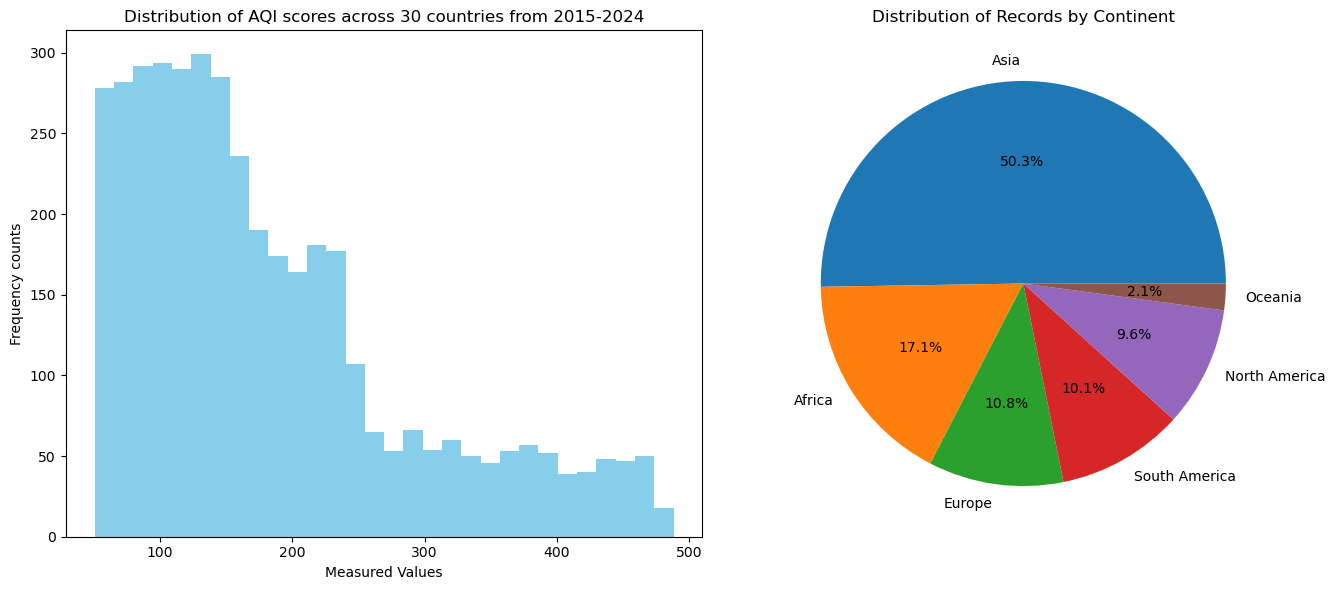

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Histogram for AQI levels across the 30 countries
ax1.hist(pollution_df['AQI'], bins=30, color='skyblue')
ax1.set_title('Distribution of AQI scores across 30 countries from 2015-2024')
ax1.set_xlabel('Measured Values')
ax1.set_ylabel('Frequency counts')

# Pie chart for portion of records by continent
continent_count = pollution_df['Continent'].value_counts()
ax2.pie(continent_count.values, labels=continent_count.index, autopct='%1.1f%%')
ax2.set_title('Distribution of Records by Continent')

plt.tight_layout()
plt.show()

The AQI scores are right-skewed with most observations clustering around 50-150. The distribution has a long tail extending to approximately 480. It is worth noting what seasons, pollutant levels, and countries corresponded to AQI scores above 400. The majority of countries lie within the Good / Moderate / Unhealthy for sensitive groups categories. From the pie chart, we can see that half of the records were collected from Asia with the second largest portion being Africa at 17.1%.

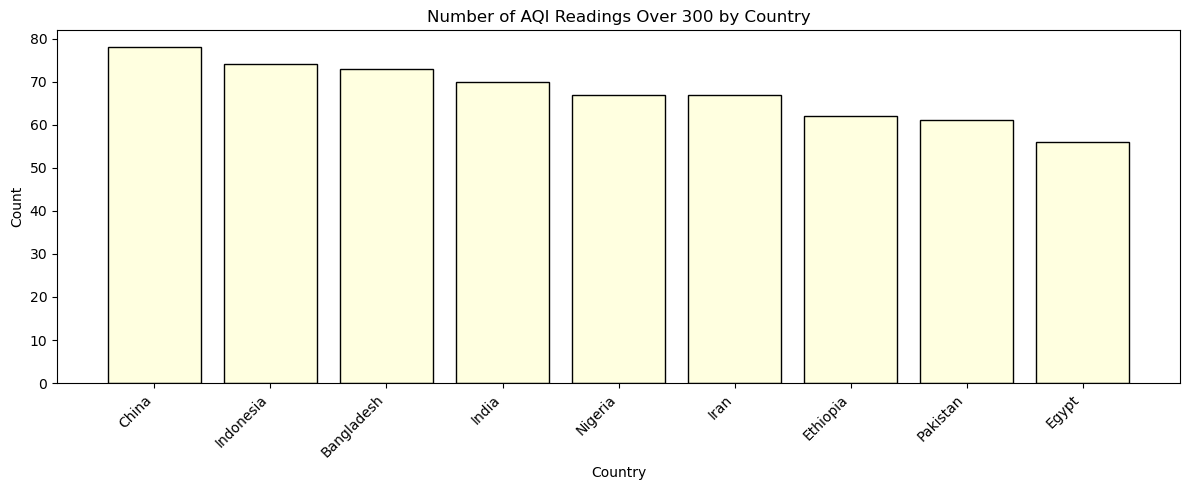

In [19]:
# Bar graph for countries and counts with AQI scores over 300
filtered = pollution_df[pollution_df['AQI'] > 300]
counts = filtered['Country'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(counts.index, counts.values, color='lightyellow', edgecolor='black')
ax.set_title('Number of AQI Readings Over 300 by Country')
ax.set_xlabel('Country')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


There are 9 countries with AQI scores above 300. The most is China with approximately 78 recordings from 2015 to 2024. Over half of the countries (6 out of 9) are in Asia. With the rest of the countries in Africa. 

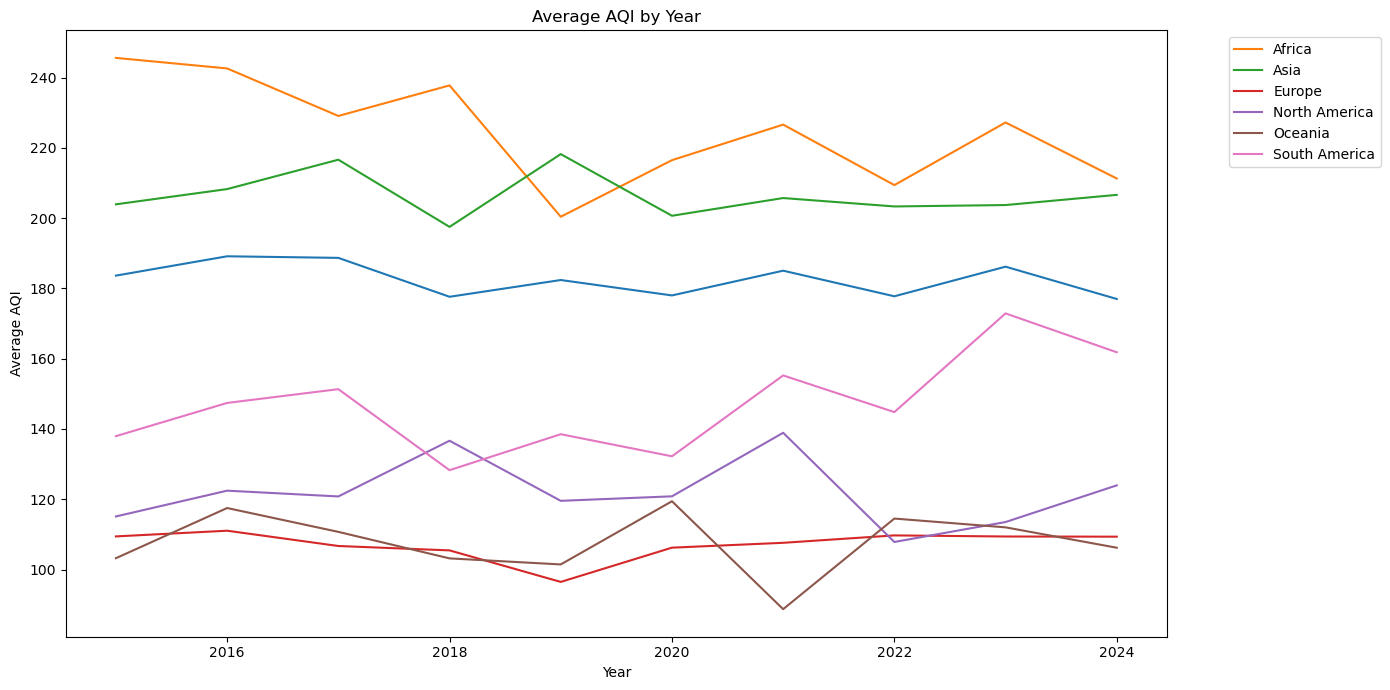

In [28]:
# Line Plot to observe trend of AQI by year 
yearly_aqi_avg = pollution_df.groupby('Year')['AQI'].mean()
yearly_aqi_continent = pollution_df.groupby(['Year', 'Continent'])['AQI'].mean()
pivoted = yearly_aqi_continent.unstack('Continent')


fig, ax = plt.subplots(figsize=(14,7)) 
ax.plot(yearly_aqi_avg.index, yearly_aqi_avg.values)
for continent in pivoted.columns: 
    ax.plot(pivoted.index, pivoted[continent], label=continent)
ax.set_title('Average AQI by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Average AQI')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

From this average AQI line plot, we can see that Africa and Asia have the highest yearly average AQI score (200-250) with Oceania and Europe consistently having the lowest scores (50-120). 

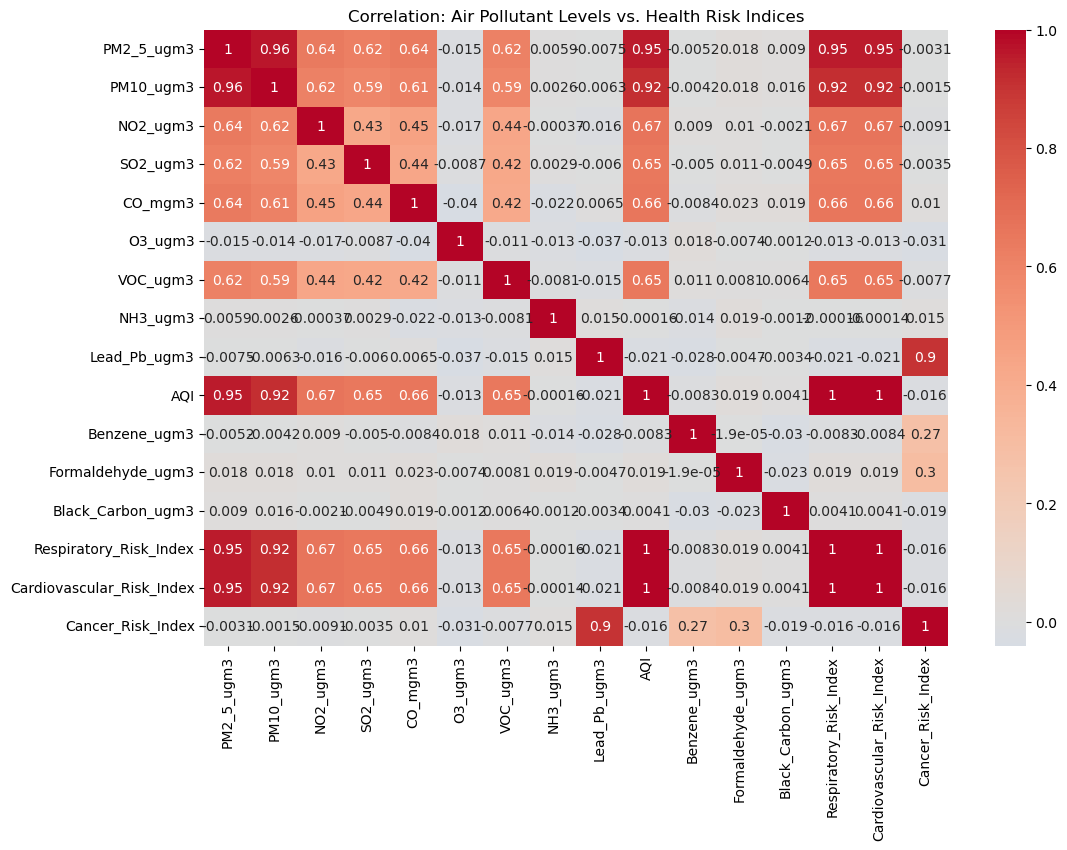

In [46]:
# Plot Heatmap of Air Pollutant levels and Health Risks + AQI Scores
isolated_cols = ['PM2_5_ugm3', 'PM10_ugm3', 'NO2_ugm3', 'SO2_ugm3', 'CO_mgm3', 'O3_ugm3', 'VOC_ugm3', 'NH3_ugm3', 'Lead_Pb_ugm3',
                 'AQI', 'Benzene_ugm3', 'Formaldehyde_ugm3', 'Black_Carbon_ugm3', 'Respiratory_Risk_Index', 'Cardiovascular_Risk_Index', 
                'Cancer_Risk_Index']
corr_matrix = pollution_df[isolated_cols].corr()

fig, ax = plt.subplots(figsize=(12,8)) 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation: Air Pollutant Levels vs. Health Risk Indices')
plt.show()